In [1]:
!pip install chromadb transformers koreanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 2.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 7.4 MB/s eta 0:00

In [2]:
# kaggle dataset 이미지 관련 자료 읽기
!wget -q https://github.com/kairess/toy-datasets/raw/master/Food-11.zip
!unzip -oq Food-11.zip

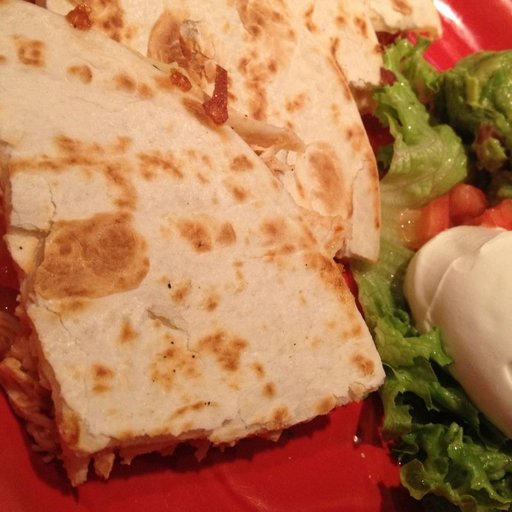

In [3]:
from PIL import Image
img = Image.open("test/Bread/0.jpg")
img

In [4]:
from transformers import ViTModel, ViTFeatureExtractor

feature_extractor = ViTFeatureExtractor.from_pretrained('facebook/dino-vits16')    # google/vit-base-patch16-224-in21k
model = ViTModel.from_pretrained('facebook/dino-vits16')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at facebook/dino-vits16 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
# 이미지 전처리
img_tensor = feature_extractor(images=img, return_tensors='pt')
print(img_tensor)

outputs = model(**img_tensor)    # * : list/tuple, ** : dict
embedding = outputs.pooler_output.detach().numpy().squeeze()
# outputs.pooler_output : 이미지 전체에 대한 요약 임베딩
# detach() : 역전파 끊기 (학습 X)
print(embedding.shape)
print(embedding[:5])

{'pixel_values': tensor([[[[ 1.0331,  1.1700,  1.3070,  ...,  2.2147,  2.2147,  1.9235],
          [ 1.2557,  1.3070,  1.3584,  ...,  2.0777,  2.2318,  2.1975],
          [ 1.4440,  1.5125,  1.5468,  ...,  1.9407,  2.1462,  2.2318],
          ...,
          [ 0.6221,  0.6049,  0.6221,  ..., -0.6623, -0.7993, -1.3473],
          [ 0.6221,  0.6221,  0.6049,  ..., -0.5082, -1.0733, -1.4843],
          [ 0.5878,  0.6221,  0.6221,  ..., -1.2103, -1.3815, -1.5357]],

         [[-0.0924,  0.1001,  0.3102,  ...,  0.7654,  0.7479,  0.3978],
          [ 0.2402,  0.3277,  0.4503,  ...,  0.3627,  0.6429,  0.6429],
          [ 0.5903,  0.6779,  0.7654,  ..., -0.0924,  0.3102,  0.5553],
          ...,
          [-1.4930, -1.5105, -1.4930,  ..., -0.8102, -0.8627, -1.3704],
          [-1.4930, -1.4930, -1.4930,  ..., -0.6702, -1.1429, -1.5105],
          [-1.5280, -1.4930, -1.4755,  ..., -1.4230, -1.4755, -1.5630]],

         [[-1.0724, -0.8633, -0.5844,  ...,  0.5485,  0.6008,  0.3219],
          [-0

model.safetensors:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

(384,)
[-0.92087924  0.8721007  -0.9977359   0.9249172   0.968148  ]


In [6]:
import chromadb
client = chromadb.Client()
collection = client.create_collection('foods')

from glob import glob    # 파일 경로에 와일드카드 * ? 사용 가능
img_list = sorted(glob('test/*/*.jpg'))
print(len(img_list))

110


In [7]:
from tqdm import tqdm
# 각 이미지에 대한 embedding, metadata, id 생성
embeddings = []
metadatas = []
ids = []

# img_list에 있는 이미지 경롤르 하나씩 처리
for i, img_path in enumerate(tqdm(img_list)):
  # 이미지 읽기
  img = Image.open(img_path)
  # 'test/Bread/0.jpg' ... 에서 Bread를 추출해 클래스명으로 사용 예정
  cls = img_path.split('/')[1]
  # print(cls)

  # pyporch 변환 작업
  img_tensor = feature_extractor(images=img, return_tensors='pt')
  outputs = model(**img_tensor)
  embedding = outputs.pooler_output.detach().numpy().squeeze().tolist()    # squeeze : 차원축소
  embeddings.append(embedding)

  metadatas.append(
      {
          'uri':img_path,
          'name': cls
        })
  ids.append(str(i))
  print('각 이미지 벡터에 저장 준비 작업 종료')


print(embeddings)
print(metadatas)
print(ids)

# VectorDB에 저장
collection.add(
    embeddings=embeddings,
    metadatas= metadatas,
    ids=ids
)

  1%|          | 1/110 [00:00<00:26,  4.07it/s]

각 이미지 벡터에 저장 준비 작업 종료


  2%|▏         | 2/110 [00:00<00:25,  4.18it/s]

각 이미지 벡터에 저장 준비 작업 종료


  3%|▎         | 3/110 [00:00<00:26,  4.09it/s]

...

각 이미지 벡터에 저장 준비 작업 종료


 99%|█████████▉| 109/110 [00:25<00:00,  4.58it/s]

각 이미지 벡터에 저장 준비 작업 종료


100%|██████████| 110/110 [00:25<00:00,  4.35it/s]

각 이미지 벡터에 저장 준비 작업 종료
[[-0.9208792448043823, 0.8721007108688354, -0.9977359175682068, 0.9249172210693359, 0.9681479930877686, -0.9634921550750732, 0.9844636917114258, -0.9608110189437866, -0.7105761170387268, -0.13494639098644257, -0.8988764882087708, -0.9413717985153198, 0.9431168437004089, -0.8228567838668823, 0.8825501203536987, -0.8341798782348633, -0.00392130995169282, -0.4257790744304657, 0.9803400635719299, 0.7055656909942627, 0.9829413294792175, 0.716887354850769, -0.9833149909973145, 0.5750731825828552, 0.31539300084114075, 0.9945845603942871, 0.28081023693084717, 0.7129939794540405, -0.6094597578048706, -0.392304927110672, 0.72632896900177, -0.9804176688194275, 0.9894039630889893, -0.869154155254364, -0.9978786706924438, -0.1248822882771492, 0.539967954158783, 0.994886040687561, 0.3974440097808838, 0.9250468611717224, -0.994708776473999, -0.4829040765762329, -0.7299672961235046, 0.9743133783340454, -0.5287684798240662, 0.9998245239257812, -0.40090957283973694, -0.997040033340

384
{'ids': [['8', '2', '6']], 'embeddings': None, 'documents': [[None, None, None]], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'name': 'Bread', 'uri': 'test/Bread/8.jpg'}, {'name': 'Bread', 'uri': 'test/Bread/2.jpg'}, {'uri': 'test/Bread/6.jpg', 'name': 'Bread'}]], 'distances': [[146.31533813476562, 253.53726196289062, 263.8036193847656]]}


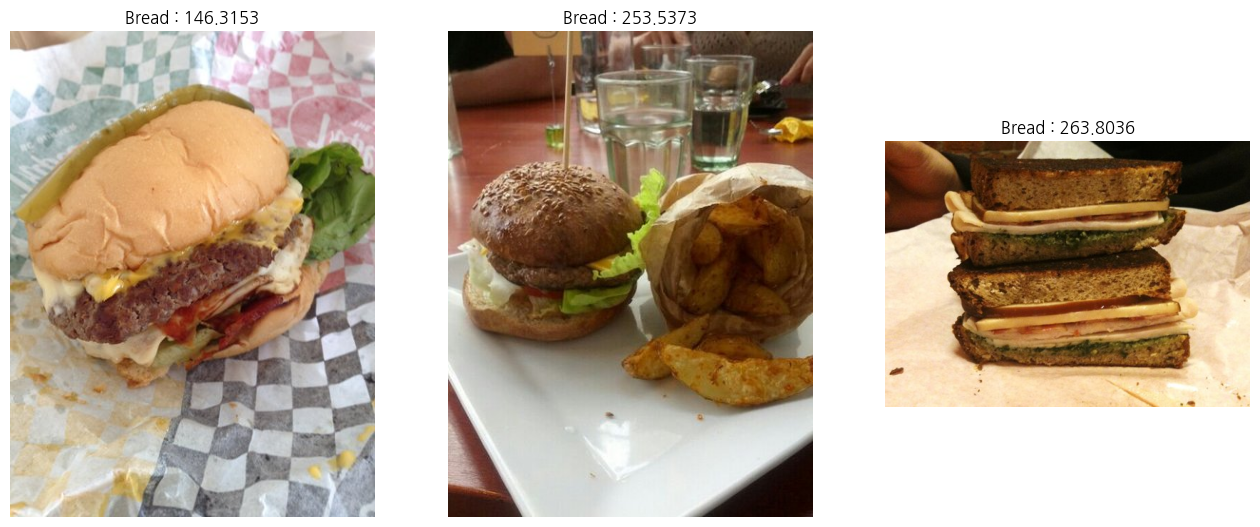

In [16]:
from torch.nn.modules import distance
import requests
test_img = Image.open(requests.get('https://i.ibb.co/7Ksr5mw/yNp6qTS.png', stream=True).raw).convert("RGB")
test_img

# 검색 이미지 전처리
test_img_tensor = feature_extractor(images=test_img, return_tensors='pt')
test_outputs = model(**test_img_tensor)
test_embedding = test_outputs.pooler_output.detach().numpy().squeeze().tolist()
print(len(test_embedding))

# 검색 대상 이미지와 유사한 이미지들을 벡터 DB에서 읽기
query_result = collection.query(
    query_embeddings=test_embedding,
    n_results=3
)
print(query_result)

# 이미지 시각화
import matplotlib.pyplot as plt
import koreanize_matplotlib
fig, axes = plt.subplots(1, 3, figsize=(16,10))
for i, metadata in enumerate(query_result['metadatas'][0]):
  distance = query_result['distances'][0][i]
  axes[i].imshow(Image.open(metadata['uri']))
  axes[i].set_title(f"{metadata['name']} : {distance:.4f}")
  axes[i].axis('off')

384
384


{'ids': [['13', '36', '50']],
 'embeddings': None,
 'documents': [[None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'name': 'Dairy product', 'uri': 'test/Dairy product/3.jpg'},
   {'uri': 'test/Egg/6.jpg', 'name': 'Egg'},
   {'name': 'Meat', 'uri': 'test/Meat/0.jpg'}]],
 'distances': [[228.40921020507812, 246.9952392578125, 253.03123474121094]]}

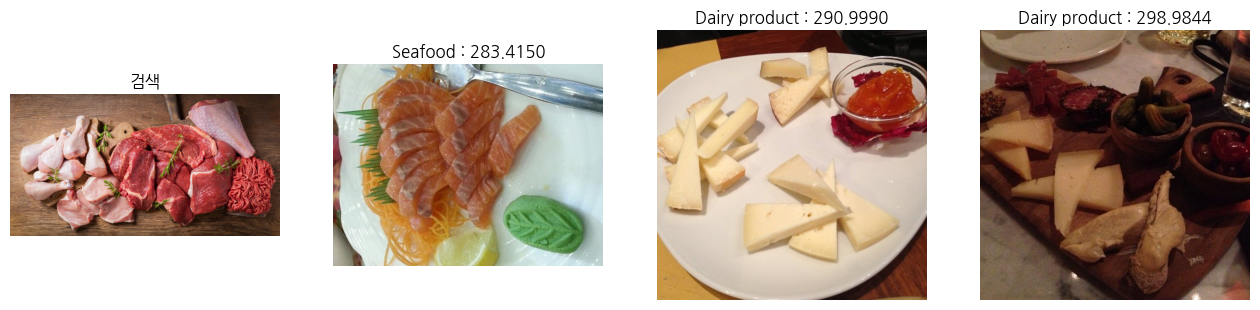

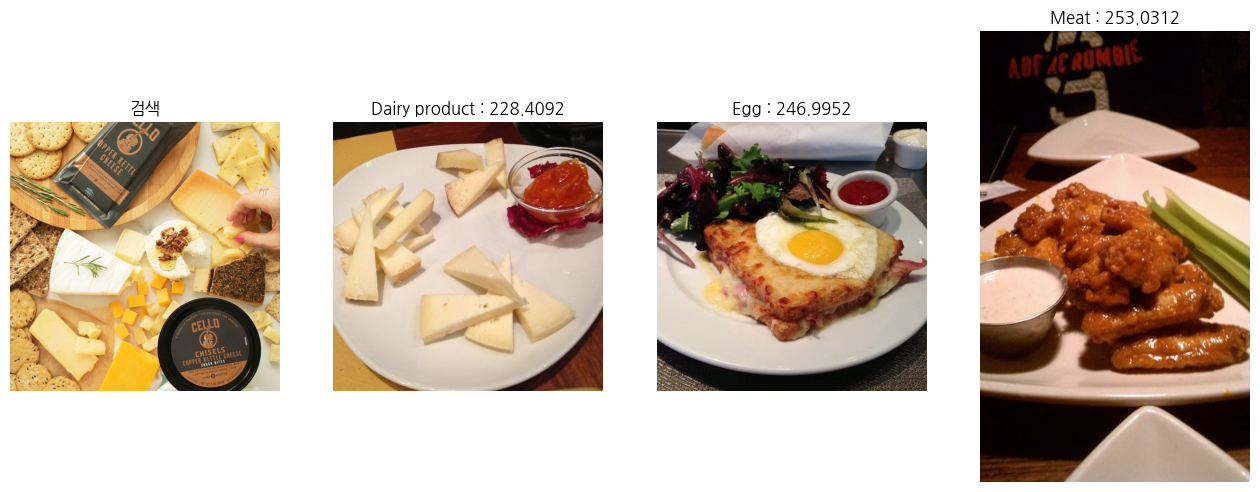

In [17]:
# 검색용 함수
def queryFunc(img_url, n_result=3):
  test_img = Image.open(requests.get(img_url, stream=True).raw).convert("RGB")
  # test_img

  # 검색 이미지 전처리
  test_img_tensor = feature_extractor(images=test_img, return_tensors='pt')
  test_outputs = model(**test_img_tensor)
  test_embedding = test_outputs.pooler_output.detach().numpy().squeeze().tolist()
  print(len(test_embedding))

  # 검색 대상 이미지와 유사한 이미지들을 벡터 DB에서 읽기
  query_result = collection.query(
      query_embeddings=test_embedding,
      n_results=3
  )
  # print(query_result)

  # 검색 이미지와 유사한 이미지들 시각화
  import matplotlib.pyplot as plt
  fig, axes = plt.subplots(1, 4, figsize=(16,10))
  axes[0].imshow(test_img)
  axes[0].set_title("검색")
  axes[0].axis('off')

  for i, metadata in enumerate(query_result['metadatas'][0]):
    distance = query_result['distances'][0][i]
    axes[i + 1].imshow(Image.open(metadata['uri']))
    axes[i + 1].set_title(f"{metadata['name']} : {distance:.4f}")
    axes[i + 1].axis('off')

  return query_result

queryFunc("https://i.ibb.co/JmpXmvx/QCado9g.jpg")
queryFunc("https://i.ibb.co/X5dkHGF/lf5C0LI-s.png")